# NHC Wind Speed Probabilities — Gridded GIS Output

Exploring how to fetch and render NHC wind speed probability shapefiles
for both operational and historical use.

Source: `windSpeedProbabilitiesGIS.zipFile5km` in `CurrentStorms.json`  
Archive: `https://www.nhc.noaa.gov/gis/forecast/archive/{YYYYMMDDHH}_wsp_120hr5km.zip`

Each zip contains **3 shapefiles** (34kt, 50kt, 64kt). Each shapefile has **11 rows** —
one pre-binned polygon per probability band — with a `PERCENTAGE` column
(`'<5%'`, `'5-10%'`, ..., `'>90%'`). This is the data behind the NHC avocado plots.

In [1]:
import io
import json
import tempfile
import zipfile

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import requests

In [2]:
with open("tests/fixtures/NHC_JSON_Sample.json") as f:
    current_storms = json.load(f)

active_storms = current_storms["activeStorms"]
print(f"{len(active_storms)} active storms in fixture")
for s in active_storms:
    wgis = s.get("windSpeedProbabilitiesGIS")
    print(
        f"  {s['id']:12s}  windSpeedProbabilitiesGIS: {wgis['zipFile5km'] if wgis else None}"
    )

4 active storms in fixture
  al062023      windSpeedProbabilitiesGIS: https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip
  al082023      windSpeedProbabilitiesGIS: https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip
  al092023      windSpeedProbabilitiesGIS: https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip
  ep092023      windSpeedProbabilitiesGIS: None


In [3]:
# Official NHC color scheme — exact match to the published avocado plots
WSP_COLORS = {
    "<5%": "none",  # transparent
    "5-10%": "#008B00",  # dark green
    "10-20%": "#00CD00",  # green
    "20-30%": "#7FFF00",  # yellow-green
    "30-40%": "#FFFF00",  # yellow
    "40-50%": "#FFD700",  # gold
    "50-60%": "#CD8500",  # dark orange
    "60-70%": "#FF7F00",  # orange
    "70-80%": "#CD0000",  # dark red
    "80-90%": "#8B0000",  # maroon
    ">90%": "#8B008B",  # purple
}

# Ordered list for legend (skip transparent <5% band)
WSP_LEGEND = [(k, v) for k, v in WSP_COLORS.items() if v != "none"]

In [4]:
def fetch_wsp_gis(zip_url: str) -> dict[int, gpd.GeoDataFrame]:
    """
    Download a NHC wind speed probability GIS zip and return a dict of
    GeoDataFrames keyed by wind threshold (34, 50, 64).

    Each GDF has 11 rows (one per probability band) and columns:
      PERCENTAGE : str  probability bin label, e.g. '5-10%'
      fill       : str  NHC hex color for that bin
      geometry   : Polygon / MultiPolygon (None for empty bands)
    """
    import os

    r = requests.get(zip_url, timeout=60)
    r.raise_for_status()
    result = {}
    with tempfile.TemporaryDirectory() as tmp:
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(tmp)
        for kt in [34, 50, 64]:
            candidates = [
                f
                for f in z.namelist()
                if f.endswith(".shp") and f"wsp{kt}knt" in f
            ]
            if not candidates:
                continue
            gdf = gpd.read_file(os.path.join(tmp, candidates[0]))
            gdf["fill"] = gdf["PERCENTAGE"].map(WSP_COLORS)
            result[kt] = gdf
    return result


def archive_wsp_gis_url(issuance: str) -> str:
    """Construct the NHC GIS archive URL from an issuance timestamp."""
    stamp = pd.Timestamp(issuance).strftime("%Y%m%d%H")
    return f"https://www.nhc.noaa.gov/gis/forecast/archive/{stamp}_wsp_120hr5km.zip"

## Operational — fetch from `CurrentStorms.json`

The GIS product is basin-wide — all active storms share the same file, linked via `windSpeedProbabilitiesGIS.zipFile5km`.

In [5]:
# The GIS product is basin-wide — all active storms share the same file.
# Use whichever storm has the link.
gis_meta = next(
    (
        s["windSpeedProbabilitiesGIS"]
        for s in active_storms
        if s.get("windSpeedProbabilitiesGIS")
        and s["windSpeedProbabilitiesGIS"].get("zipFile5km")
    ),
    None,
)

if gis_meta:
    gis_issuance = gis_meta["issuance"]
    print(f"Issuance : {gis_issuance}")
    print(f"URL      : {gis_meta['zipFile5km']}")
    wsp_gis = fetch_wsp_gis(gis_meta["zipFile5km"])
    for kt, gdf in wsp_gis.items():
        n_bands = (
            gdf["geometry"].notna() & (gdf["PERCENTAGE"] != "<5%")
        ).sum()
        print(f"  {kt}kt: {n_bands} non-empty probability bands")
else:
    print("No GIS product in fixture")

Issuance : 2023-08-22T00:00:00.000Z
URL      : https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip


  34kt: 10 non-empty probability bands
  50kt: 4 non-empty probability bands
  64kt: 0 non-empty probability bands


In [6]:
# The schema: 11 rows (one per band), PERCENTAGE + fill + geometry
wsp_gis[34][["PERCENTAGE", "fill", "geometry"]].head(11)

,PERCENTAGE,fill,geometry
0,<5%,none,"MULTIPOLYGON (((-95.95576 24.467, -95.95576 24..."
1,5-10%,#008B00,"MULTIPOLYGON (((-95.77594 25.05143, -95.77594 ..."
2,10-20%,#00CD00,"MULTIPOLYGON (((-96.00072 25.36612, -96.00072 ..."
3,20-30%,#7FFF00,"MULTIPOLYGON (((-95.59612 25.68081, -95.59612 ..."
4,30-40%,#FFFF00,"MULTIPOLYGON (((-69.92627 13.4528, -69.92627 1..."
5,40-50%,#FFD700,"MULTIPOLYGON (((-70.06114 13.58766, -70.06114 ..."
6,50-60%,#CD8500,"MULTIPOLYGON (((-70.01618 13.67758, -70.01618 ..."
7,60-70%,#FF7F00,"POLYGON ((-70.01618 13.76749, -70.01618 13.812..."
8,70-80%,#CD0000,"POLYGON ((-69.88132 13.81244, -69.88132 13.857..."
9,80-90%,#8B0000,"MULTIPOLYGON (((-69.47671 13.94731, -69.47671 ..."


### 2b. Avocado plot — single threshold

In [7]:
def plot_avocado(
    wsp_gis: dict[int, gpd.GeoDataFrame],
    wind_threshold_kt: int = 34,
    issuance: str = "",
    ax=None,
    show_legend: bool = True,
):
    """
    Reproduce the NHC avocado plot for a single wind threshold.

    Parameters
    ----------
    wsp_gis           dict from fetch_wsp_gis()
    wind_threshold_kt 34, 50, or 64
    issuance          label string for the plot title
    ax                existing matplotlib Axes, or None to create
    show_legend       whether to draw the probability color legend
    """
    gdf = wsp_gis[wind_threshold_kt].copy()
    gdf = gdf[gdf["geometry"].notna()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 7))

    ax.set_facecolor("#d0e8f0")  # ocean background

    # Plot each band — skip transparent '<5%'
    for _, row in gdf.iterrows():
        if row["fill"] == "none":
            continue
        gpd.GeoDataFrame([row], geometry="geometry", crs=gdf.crs).plot(
            ax=ax,
            color=row["fill"],
            edgecolor="none",
        )

    # Fit extent to the data, with padding
    bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
    pad = 5
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

    if show_legend:
        handles = [
            mpatches.Patch(
                facecolor=color, edgecolor="#888", linewidth=0.3, label=label
            )
            for label, color in WSP_LEGEND
        ]
        ax.legend(
            handles=handles,
            title="Probability",
            loc="lower left",
            fontsize=8,
            title_fontsize=8,
            framealpha=0.9,
        )

    kt_label = {
        34: "Tropical-Storm-Force (≥34 kt)",
        50: "Gale-Force (≥50 kt)",
        64: "Hurricane-Force (≥64 kt)",
    }
    ax.set_title(
        f"NHC 5-Day {kt_label[wind_threshold_kt]} Wind Probability\n"
        f"Cumulative 0–120 hr  |  {issuance}",
        fontsize=10,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    return ax

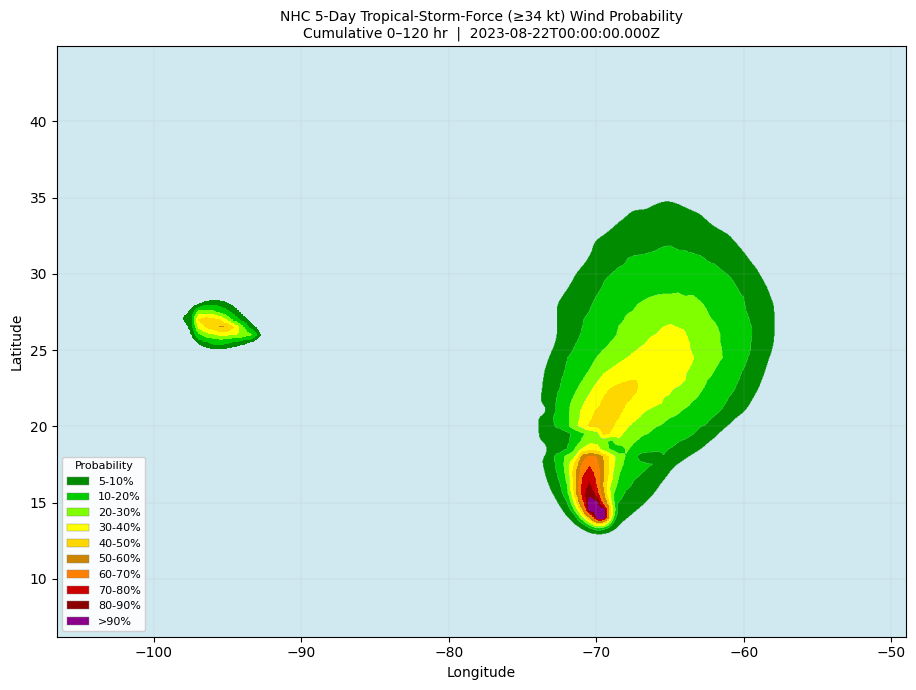

In [8]:
plot_avocado(wsp_gis, wind_threshold_kt=34, issuance=gis_issuance)
plt.tight_layout()
plt.show()

### 2c. All three thresholds side by side

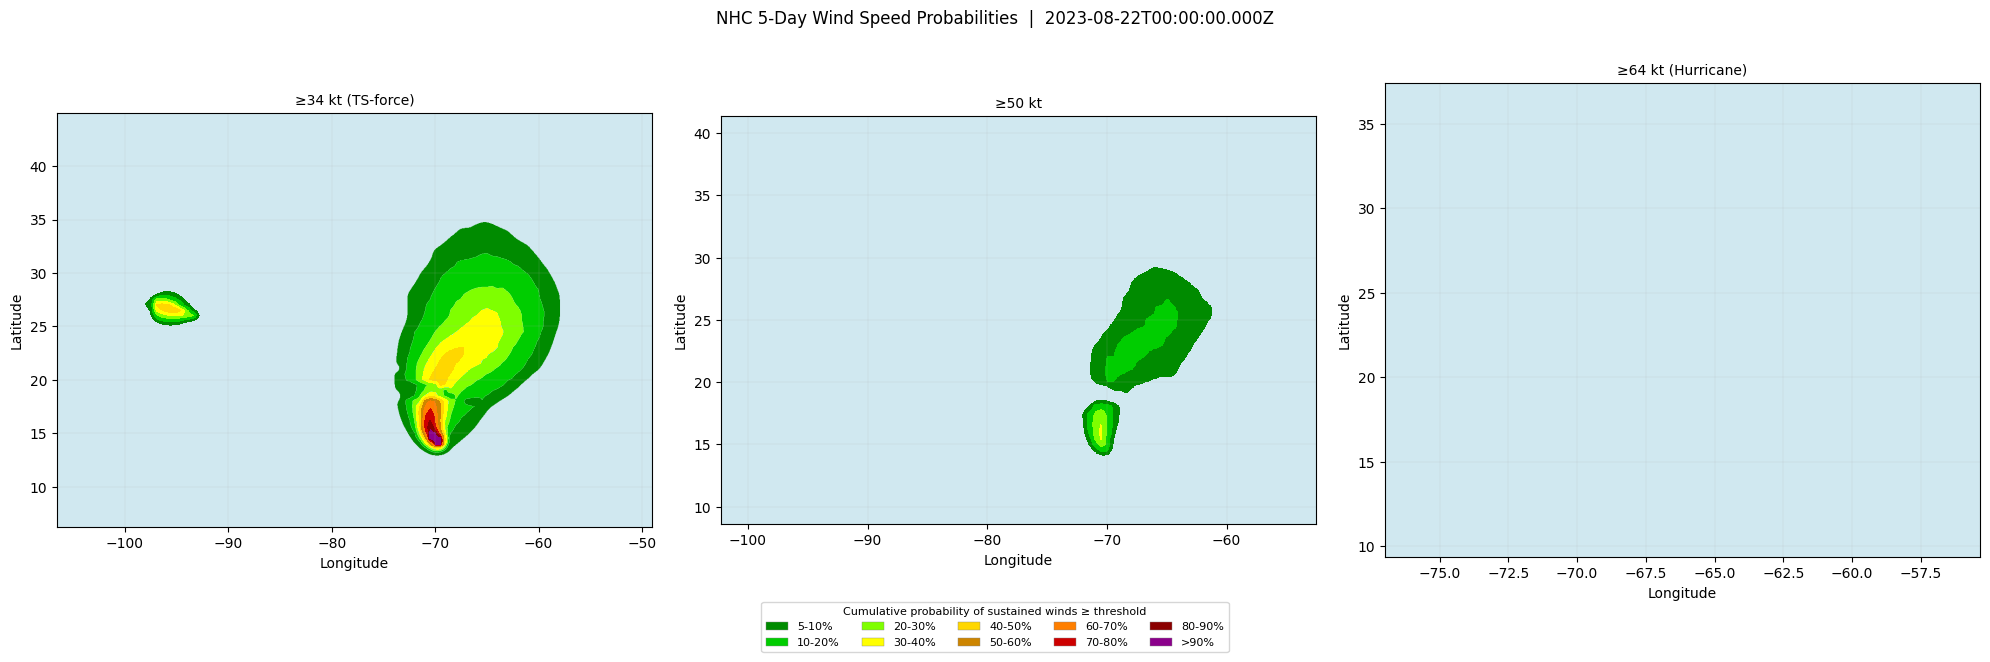

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
kt_labels = {34: "≥34 kt (TS-force)", 50: "≥50 kt", 64: "≥64 kt (Hurricane)"}

for ax, kt in zip(axes, [34, 50, 64]):
    plot_avocado(
        wsp_gis,
        wind_threshold_kt=kt,
        issuance=gis_issuance,
        ax=ax,
        show_legend=False,
    )
    ax.set_title(kt_labels[kt], fontsize=10)

# Single shared legend below all panels
handles = [
    mpatches.Patch(
        facecolor=color, edgecolor="#888", linewidth=0.3, label=label
    )
    for label, color in WSP_LEGEND
]
fig.legend(
    handles=handles,
    title="Cumulative probability of sustained winds ≥ threshold",
    loc="lower center",
    ncol=5,
    fontsize=8,
    title_fontsize=8,
    bbox_to_anchor=(0.5, -0.07),
)
fig.suptitle(
    f"NHC 5-Day Wind Speed Probabilities  |  {gis_issuance}",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

## Historical archive — fetch by issuance timestamp

`windSpeedProbabilitiesGIS.issuance` maps directly to the archive filename.
The GIS product is updated every 6 hours at round UTC times (00, 06, 12, 18Z).

In [10]:
# The fixture GIS issuance is 2023-08-22T00:00:00Z, which matches the archive filename
archive_url = archive_wsp_gis_url("2023-08-22T00:00:00.000Z")
print(f"Archive URL: {archive_url}")

wsp_gis_archive = fetch_wsp_gis(archive_url)
for kt, gdf in wsp_gis_archive.items():
    n_bands = (gdf["geometry"].notna() & (gdf["PERCENTAGE"] != "<5%")).sum()
    print(f"  {kt}kt: {n_bands} non-empty probability bands")

Archive URL: https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip
  34kt: 10 non-empty probability bands
  50kt: 4 non-empty probability bands
  64kt: 0 non-empty probability bands


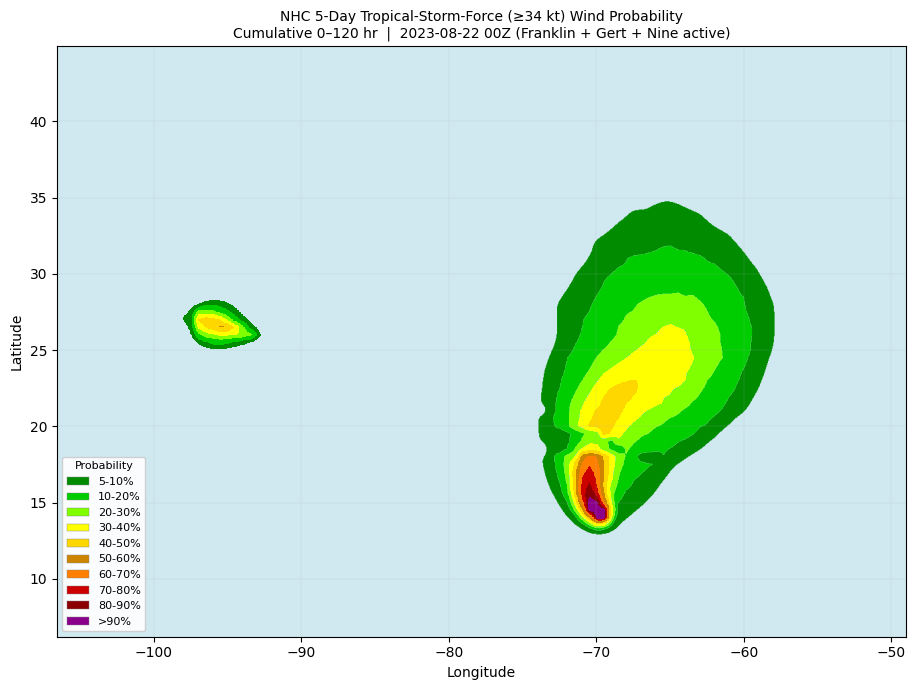

In [11]:
plot_avocado(
    wsp_gis_archive,
    wind_threshold_kt=34,
    issuance="2023-08-22 00Z (Franklin + Gert + Nine active)",
)
plt.tight_layout()
plt.show()

---
## Output schema

`fetch_wsp_gis()` returns a `dict[int, GeoDataFrame]` keyed by wind threshold.
Each GeoDataFrame has 11 rows — one per probability band:

| Column | Type | Notes |
|---|---|---|
| `PERCENTAGE` | str | Probability bin: `'<5%'`, `'5-10%'`, ..., `'>90%'` |
| `fill` | str | NHC hex color for that bin |
| `geometry` | Polygon/MultiPolygon | Area with ≥ that probability (`None` if band is empty) |

**Basin-wide** — covers all active storms simultaneously. No `atcf_id`.

**Issuance** is always a round 6-hr UTC timestamp, which maps 1:1 to the archive filename.